In [2]:
from scipy.io import loadmat
import numpy as np

import requests
import tarfile

from pathlib import Path
import re
import shutil
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision.io import decode_image
from torch.utils.data import Dataset
from torchinfo import summary
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Data splits

In [9]:
def download_file(url, download_path):
    # Download the file with streaming to handle large files efficiently
    print(f"Downloading from: {url}")
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status() # Raise an exception for bad status codes
            with open(download_path, 'wb') as f:
                shutil.copyfileobj(r.raw, f)
        print(f"Download complete: {download_path}")
    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

def download_and_extract_tgz(url, download_path, extract_path):
    # 1. Ensure the extract directory exists
    os.makedirs(extract_path, exist_ok=True)
    print(f"Ensured extraction directory exists: {extract_path}")

    # 2. Download the file with streaming to handle large files efficiently
    print(f"Downloading from: {url}")
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status() # Raise an exception for bad status codes
            with open(download_path, 'wb') as f:
                shutil.copyfileobj(r.raw, f)
        print(f"Download complete: {download_path}")

        # 3. Extract the .tgz file
        print(f"Extracting to: {extract_path}")
        with tarfile.open(download_path, 'r:gz') as tar_file:
            tar_file.extractall(path=extract_path)
        print("Extraction complete.")

    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
    except tarfile.TarError as e:
        print(f"Extraction failed: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        # Optional: Remove the downloaded .tgz file after extraction
        if os.path.exists(download_path):
            os.remove(download_path)
            print(f"Removed temporary download file: {download_path}")

In [ ]:
# download dataset:
dataset_url = 'https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz'
temp_file_name = 'images.tgz'
destination_folder = './data'
download_and_extract_tgz(dataset_url, temp_file_name, destination_folder)

# download metadata files
metadata_files = [('https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat','./data/imagelabels.mat'),
                  ('https://www.robots.ox.ac.uk/~vgg/data/flowers/102/setid.mat', './data/setid.mat')
                  ]

for url, file in metadata_files:
    download_file(url, file)

Download complete: ./data/imagelabels.mat
Download complete: ./data/setid.mat


In [3]:
def ensure_split_folder(split_dir, split_ids, labels, source_dir="./data/jpg"):
    source_path = Path(source_dir)
    target_path = Path(split_dir)

    if target_path.exists():
        print(f"{target_path} already exists; skipping creation.")
        return target_path

    target_path.mkdir(parents=True, exist_ok=True)
    split_id_set = set(np.asarray(split_ids).reshape(-1).astype(int).tolist())
    labels_arr = np.asarray(labels).reshape(-1).astype(int)

    copied = 0
    for file_path in tqdm(source_path.iterdir()):
        if not file_path.is_file():
            continue

        match = re.search(r"(\d+)(?!.*\d)", file_path.stem)
        if not match:
            continue

        sample_id = int(match.group(1))
        if sample_id not in split_id_set:
            continue

        label = int(labels_arr[sample_id - 1])
        label_dir = target_path / str(label)
        label_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(file_path, label_dir / file_path.name)
        copied += 1

    print(f"Created {target_path} with {copied} files.")
    return target_path


In [4]:
# define directory names
root_dir = './data'
src_dir = './data/jpg' # this is just where i have all the pics
train_dir = './data/train'
val_dir = './data/val'
test_dir = './data/test'

# load in set splits
setid = loadmat("./data/setid.mat")
labels = loadmat("./data/imagelabels.mat")['labels']
train = setid['trnid']
val = setid['valid']
test = setid['tstid']

# split data into train, val, test
# we just copyin for now since the dataset is so small
ensure_split_folder(train_dir, train, labels)
ensure_split_folder(val_dir, val, labels)
ensure_split_folder(test_dir, test, labels)


data/train already exists; skipping creation.
data/val already exists; skipping creation.
data/test already exists; skipping creation.


PosixPath('data/test')

## DataLoader definitions

In [5]:
# first calculate stats on the train set for transformation normalization
mean = 0
std = 0
n = 0

all_paths = [p for p in Path(train_dir).rglob("*") if p.is_file()]

for path in all_paths:
    img = decode_image(str(path)).float().to(device)

    img = img.view(3, -1)
    mean += img.mean(1).to('cpu')
    std += img.std(1).to('cpu')
    n += 1

mean /= n
std /= n


In [6]:
# two views for contrastive objective
class TwoViewTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):
        view1 = self.base_transform(x)
        view2 = self.base_transform(x)
        return view1, view2
    
simclr_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply(
        [T.ColorJitter(0.4, 0.4, 0.4, 0.1)],
        p=0.8
    ),
    #T.RandomGrayscale(p=0.2), # OG SimCLR doesnt use this
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(mean, std)
])

# make datasets
train_dataset = ImageFolder(
    root=train_dir,
    transform=TwoViewTransform(simclr_transform)
)

val_dataset = ImageFolder(
    root=val_dir,
    transform=TwoViewTransform(simclr_transform)
)

test_dataset = ImageFolder(
    root=test_dir,
    transform=TwoViewTransform(simclr_transform)
)

# make loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

## SimCLR Model

In [7]:
class SimCLR(nn.Module):
    def __init__(self, out_features=128):
        super().__init__()
        self.resnet18 = resnet18()
        
        # replace last layer with linear projection head
        num_features = self.resnet18.fc.in_features
        self.resnet18.fc = nn.Linear(num_features, num_features)

        self.relu = nn.ReLU()
        self.fc = nn.Linear(num_features, out_features)        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y_pred = self.resnet18(x)
        y_pred = self.relu(y_pred)
        y_pred = self.fc(y_pred)
        return y_pred
    
    @torch.no_grad()
    def representation(self, x: torch.Tensor) -> torch.Tensor:
        return self.resnet18(x)

In [10]:
for i in tqdm(test_loader):
    len(i)

  0%|          | 0/96 [00:00<?, ?it/s]Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=91, pipe_handle=127)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'TwoViewTransform' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
  0%|          | 0/96 [00:01<?, ?it/s]


BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
import torch
import torch.nn.functional as F

def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.2) -> torch.Tensor:
    if z1.ndim != 2 or z2.ndim != 2:
        raise ValueError(f"z1 and z2 must be 2D (B,D). Got {z1.shape} and {z2.shape}.")
    if z1.shape != z2.shape:
        raise ValueError(f"z1 and z2 must have the same shape. Got {z1.shape} vs {z2.shape}.")

    B, D = z1.shape
    if B < 2:
        raise ValueError("Batch size must be >= 2 for contrastive loss (needs negatives).")

    # 1) Normalize to unit length for cosine similarity
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # concatenate for a (2B, D) tensor
    z = torch.cat([z1, z2], dim=0)  # (2B, D)

    # cosine similarity
    sim = F.cosine_similarity(z[None,:,:], z[:,None,:], dim=-1)
    
    # mask self similarity
    sim[torch.eye(z.size(0)).bool()] = float("-inf")

    # positive indices:
    # For i in [0..B-1] (z1), positive is i+B (z2)
    # For i in [B..2B-1] (z2), positive is i-B (z1)
    pos_idx = torch.arange(2 * B, device=z.device)
    pos_idx = (pos_idx + B) % (2 * B)

    # cross-entropy loss where each anchor predicts its positive among 2B-1 candidates
    # Targets: for each row i, the positive is at column pos_idx[i]
    loss = F.cross_entropy(sim/temperature, pos_idx)

    return loss

## Train SimCLR

In [9]:
simCLR = SimCLR().to(device)
lr = 1e-3
epochs = 150
opt = torch.optim.Adam(simCLR.parameters(), lr=lr)
history = {"train_loss": []}

simCLR.train()
for ep in range(1, epochs + 1):
    running = 0.0
    n_batches = 0
    pbar = tqdm(train_loader, desc=f"epoch {ep}/{epochs}")
    for sample in pbar:
        (x1, x2), label = sample
        x1 = x1.to(device)
        x2 = x2.to(device)

        z1 = simCLR(x1)
        z2 = simCLR(x2)
       
        loss = nt_xent_loss(z1, z2)
        opt.zero_grad()
        loss.backward()
        opt.step()

        running += float(loss.item())
        n_batches += 1
        pbar.set_postfix(loss=running / n_batches)
    train_loss = running / max(1, n_batches)
    history["train_loss"].append(train_loss)
    print(f"epoch {ep}: train_loss={train_loss:.4f}")

epoch 1/150: 100%|██████████| 15/15 [00:26<00:00,  1.75s/it, loss=4.48]


epoch 1: train_loss=4.4755


epoch 2/150: 100%|██████████| 15/15 [00:25<00:00,  1.71s/it, loss=4.17]


epoch 2: train_loss=4.1727


epoch 3/150: 100%|██████████| 15/15 [00:25<00:00,  1.68s/it, loss=4.12]


...

epoch 148: train_loss=1.2186


epoch 149/150: 100%|██████████| 15/15 [00:25<00:00,  1.67s/it, loss=1.2] 


epoch 149: train_loss=1.2028


epoch 150/150: 100%|██████████| 15/15 [00:25<00:00,  1.71s/it, loss=1.2] 

epoch 150: train_loss=1.1960


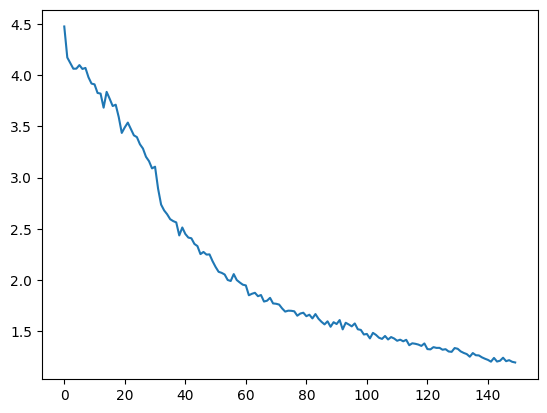

In [10]:
from matplotlib import pyplot as plt
plt.plot(history['train_loss'])